In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch.nn as nn

In [2]:
df = pd.read_csv("../Veriler/Iris.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

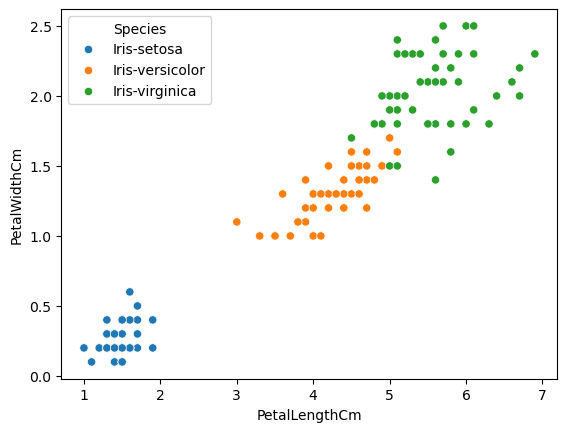

In [7]:
sns.scatterplot(x=df['PetalLengthCm'], y=df['PetalWidthCm'], hue=df["Species"])
plt.show()

In [8]:
df.drop('Id', axis=1,inplace=True)
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [9]:
x = df[['SepalLengthCm',"SepalWidthCm","PetalLengthCm","PetalWidthCm"]].values
y = df["Species"].values

In [10]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [11]:
# label encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
# y'deki sınıflara birer label atıyor.
le = LabelEncoder() 
y = le.fit_transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)
# statify -> rastgele seçilirken oranın korunmasını sağlar.

In [15]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)
print(y_train.shape, y_test.shape)

torch.Size([120]) torch.Size([30])


In [16]:
class MultiClassClasification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(4,16),
            nn.ReLU(),
            nn.Linear(16,16),
            nn.ReLU(),
            nn.Linear(16,3),
        )
        # self.layer_1 = nn.Linear(in_features=4,out_features=10)
        # self.layer_2 = nn.Linear(in_features=10,out_features=16)
        # self.layer_3 = nn.Linear(in_features=16,out_features=3)
        # self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear_layer_stack(x)
        # return self.layer_3(self.ralu(self.layer_2(self.relu(self.layer_1(x)))))

In [17]:
model = MultiClassClasification()
model = torch.compile(model)

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.003)

In [19]:
def calculate_accuracy(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy = (correct / len(y_pred)) *100
    return accuracy

In [20]:
epochs = 200
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    
    logits = model(x_train)
    loss = loss_fn(logits,y_train)
    
    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = calculate_accuracy(y_train,pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step() 

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    model.eval()
    with torch.inference_mode():
        test_logit = model(x_test)
        test_loss = loss_fn(test_logit,y_test)
        test_pred = torch.argmax(test_logit, dim=1)
        test_acc = calculate_accuracy(y_test,test_pred)

    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch 0 | Loss: 1.7268 | Acc: 33.33% | Test Loss: 1.5727 | Test Acc: 33.33%
Epoch 20 | Loss: 1.0127 | Acc: 33.33% | Test Loss: 1.0077 | Test Acc: 33.33%
Epoch 40 | Loss: 0.8528 | Acc: 90.83% | Test Loss: 0.8437 | Test Acc: 90.00%
Epoch 60 | Loss: 0.6599 | Acc: 69.17% | Test Loss: 0.6503 | Test Acc: 73.33%
Epoch 80 | Loss: 0.4681 | Acc: 87.50% | Test Loss: 0.4624 | Test Acc: 86.67%
Epoch 100 | Loss: 0.3543 | Acc: 96.67% | Test Loss: 0.3564 | Test Acc: 93.33%
Epoch 120 | Loss: 0.2721 | Acc: 96.67% | Test Loss: 0.2779 | Test Acc: 100.00%
Epoch 140 | Loss: 0.2008 | Acc: 97.50% | Test Loss: 0.2098 | Test Acc: 100.00%
Epoch 160 | Loss: 0.1479 | Acc: 97.50% | Test Loss: 0.1591 | Test Acc: 100.00%
Epoch 180 | Loss: 0.1146 | Acc: 97.50% | Test Loss: 0.1260 | Test Acc: 100.00%


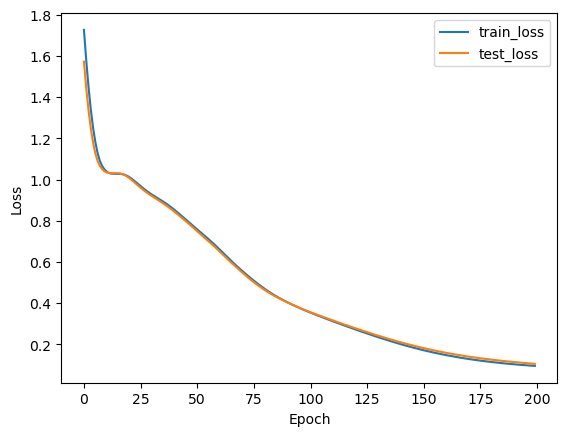

In [21]:
plt.plot(train_losses, label="train_loss")
plt.plot(test_losses, label="test_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

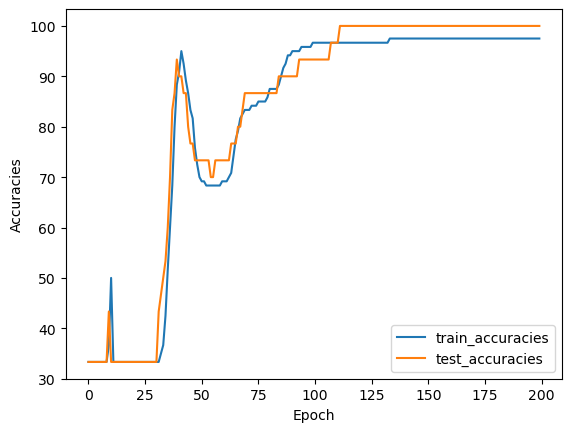

In [22]:
plt.plot(train_accuracies, label="train_accuracies")
plt.plot(test_accuracies, label="test_accuracies")
plt.xlabel("Epoch")
plt.ylabel("Accuracies")
plt.legend()
plt.show()

In [23]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
new_sample = np.array([[5.1,3.5,1.4,0.2]])

In [25]:
new_sample_tensor = torch.tensor(new_sample, dtype=torch.float32)

In [26]:
new_sample_tensor.shape

torch.Size([1, 4])

In [27]:
model.eval()
with torch.inference_mode():
    logits = model(new_sample_tensor)
    probs = torch.softmax(logits,dim=1)
    predicted_class = torch.argmax(probs,dim=1).item()

In [28]:
print(predicted_class)

0


In [29]:
le.inverse_transform([predicted_class]).item()

'Iris-setosa'

In [30]:
# torchmetrics

In [31]:
from torchmetrics.classification import MulticlassAccuracy

In [32]:
accuracy = MulticlassAccuracy(num_classes=3)

In [33]:
epochs = 200
model2 = MultiClassClasification()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.003)

for epoch in range(epochs):
    
    model2.train()
    
    logits = model2(x_train)
    loss = loss_fn(logits,y_train)
    pred = torch.softmax(logits, dim=1).argmax(dim=1)
    acc = accuracy(pred, y_train).item() * 100 # 0.35 gibi verdiği için 100 ile çarpıyoruz.

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model2.eval()
    with torch.inference_mode():
        test_logits = model2(x_test)
        test_loss   = loss_fn(test_logits,y_test)
        test_pred   = torch.softmax(test_logits, dim =1).argmax(dim=1)
        test_acc    = accuracy(test_pred, y_test).item() * 100

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss:{loss}, Acc:{acc}, Test Loss:{test_loss}, Test Acc:{test_acc}")

Epoch 0, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 20, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 40, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 60, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 80, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 100, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 120, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 140, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066, Test Acc:33.33333432674408
Epoch 160, Loss:1.1025481224060059, Acc:33.33333432674408, Test Loss:1.104960322380066